# Tutorial 55: Compare Calculations

The Tutorial demonstrates how to execute calculations for the **same model** in adjusted valve positions (Betriebszustandsdaten/Operational status data) and view the individual results.

# Imports

## SIR 3S Toolkit

### Regular Import/Init

In [1]:
SIR3S_SIRGRAF_DIR = r"C:\3S\SIR 3S\SirGraf-90-15-00-24_Quebec-Upd2" #change to local path

In [2]:
from sir3stoolkit.core import wrapper

In [3]:
wrapper

<module 'sir3stoolkit.core.wrapper' from 'C:\\Users\\aUsername\\3S\\sir3stoolkit\\src\\sir3stoolkit\\core\\wrapper.py'>

In [4]:
wrapper.Initialize_Toolkit(SIR3S_SIRGRAF_DIR)

[2026-06-08 11:19:56,355] INFO in sir3stoolkit.core.wrapper: [Initialization] Using provided SirGraf path: C:\3S\SIR 3S\SirGraf-90-15-00-24_Quebec-Upd2
[2026-06-08 11:19:56,355] INFO in sir3stoolkit.core.wrapper: [Initialization] Using provided SirGraf path: C:\3S\SIR 3S\SirGraf-90-15-00-24_Quebec-Upd2
[2026-06-08 11:19:56,416] INFO in sir3stoolkit.core.wrapper: [Initialization] Initializing toolkit with SirGraf path: C:\3S\SIR 3S\SirGraf-90-15-00-24_Quebec-Upd2


### Additional Import/Init for Dataframes class

In [5]:
from sir3stoolkit.mantle.mantle import SIR3S_Model_Mantle

In [6]:
s3s = SIR3S_Model_Mantle()

[2026-06-08 11:20:17,756] INFO in sir3stoolkit.core.wrapper: [Model Class Initialization] Initialization complete


## Additional

In [7]:
import matplotlib.pyplot as plt

In [8]:
import networkx as nx

# Open Model

For the tutorial we have a simple hydraulic setup. A node with 4 t/h net outflow simulates some consumption. It is supplied by two pipes. The one from the left has a boundary pressure of 6 bar and a valve, we will control, the one from the right has a boundary pressure of 3 bar and no valve.

In [9]:
s3s.OpenModel(dbName=r"Toolkit_Tutorial55_Model.db3",
              providerType=s3s.ProviderTypes.SQLite,
              Mid="M-1-0-1",
              saveCurrentlyOpenModel=False,
              namedInstance="",
              userID="",
              password="")

[2026-06-08 11:20:33,712] INFO in sir3stoolkit.core.wrapper: Model is open for further operation


Valves:
- 'bz.Indphi': -1: geschlossen, 0: offen, 1: Tabellenverweis, 2: variabel
- 'bz.Phio': Stellung offen [%]
- 'bz.Phig': Stellung geschlossen [%]
- 'bz.Phisoll': Stellung variabel [%]
- 'bz.Fkphi1',
- 'bz.Tiv',
- 'bz.IndPhiKonst',
- 'bz.IndphiKlartext'

# Get Tk

In [10]:
valve = s3s.GetTksofElementType(s3s.ObjectTypes.Valve)[0]

# 1. Scenario: Valve open (100%)

In [11]:
s3s.SetValue(Tk=valve, propertyName="bz.Indphi", Value="0")

[2026-06-08 11:20:33,898] INFO in sir3stoolkit.core.wrapper: Value is set


In [12]:
s3s.ExecCalculation(True)

[2026-06-08 11:20:38,894] INFO in sir3stoolkit.core.wrapper: Model Calculation is complete


In [13]:
df_edges_1 = s3s.generate_edge_dataframe()

[2026-06-08 11:20:39,000] INFO in sir3stoolkit.mantle.dataframes: [edge dataframe] Generating dataframe for ObjectTypes.Pipe ...


[2026-06-08 11:20:39,048] INFO in sir3stoolkit.mantle.dataframes: [model_data] Generating model_data dataframe for element type: ObjectTypes.Pipe
[2026-06-08 11:20:39,054] INFO in sir3stoolkit.mantle.dataframes: [model_data] Retrieved 2 element(s) of element type ObjectTypes.Pipe.
[2026-06-08 11:20:39,061] INFO in sir3stoolkit.mantle.dataframes: [Resolving model_data Properties] Using 1 model_data properties.
[2026-06-08 11:20:39,063] INFO in sir3stoolkit.mantle.dataframes: [model_data] Retrieving model_data properties ['Fkcont'], geometry, end nodes...
[2026-06-08 11:20:39,524] INFO in sir3stoolkit.mantle.dataframes: [model_data] 2 non-empty end node columns were created.
[2026-06-08 11:20:39,590] WARNING in sir3stoolkit.mantle.dataframes: [model_data] Spatial Reference Identifier (SRID) not defined in model. DataFrame cannot be transformed to GeoDataFrame but geometry column can be created independently of SRID. Returning regular DataFrame with a geometry column.
[2026-06-08 11:20:39

In [14]:
df_pipes_1, _ = s3s.generate_element_dataframe(s3s.ObjectTypes.Pipe)

[2026-06-08 11:20:41,205] INFO in sir3stoolkit.mantle.dataframes: [generate_element_dataframe] Generating df for element type: ObjectTypes.Pipe ...
[2026-06-08 11:20:41,207] INFO in sir3stoolkit.mantle.dataframes: [generate_element_dataframe] Generating df_model_data for element type: ObjectTypes.Pipe ...
[2026-06-08 11:20:41,221] INFO in sir3stoolkit.mantle.dataframes: [model_data] Generating model_data dataframe for element type: ObjectTypes.Pipe
[2026-06-08 11:20:41,225] INFO in sir3stoolkit.mantle.dataframes: [model_data] Retrieved 2 element(s) of element type ObjectTypes.Pipe.
[2026-06-08 11:20:41,231] INFO in sir3stoolkit.mantle.dataframes: [Resolving model_data Properties] No properties given → using ALL model_data properties for ObjectTypes.Pipe.
[2026-06-08 11:20:41,232] INFO in sir3stoolkit.mantle.dataframes: [Resolving model_data Properties] Using 46 model_data properties.
[2026-06-08 11:20:41,235] INFO in sir3stoolkit.mantle.dataframes: [model_data] Retrieving model_data pr

In [15]:
df_nodes_1, _ = s3s.generate_element_dataframe(s3s.ObjectTypes.Node)

[2026-06-08 11:20:45,054] INFO in sir3stoolkit.mantle.dataframes: [generate_element_dataframe] Generating df for element type: ObjectTypes.Node ...
[2026-06-08 11:20:45,058] INFO in sir3stoolkit.mantle.dataframes: [generate_element_dataframe] Generating df_model_data for element type: ObjectTypes.Node ...
[2026-06-08 11:20:45,254] INFO in sir3stoolkit.mantle.dataframes: [model_data] Generating model_data dataframe for element type: ObjectTypes.Node
[2026-06-08 11:20:45,262] INFO in sir3stoolkit.mantle.dataframes: [model_data] Retrieved 4 element(s) of element type ObjectTypes.Node.
[2026-06-08 11:20:45,269] INFO in sir3stoolkit.mantle.dataframes: [Resolving model_data Properties] No properties given → using ALL model_data properties for ObjectTypes.Node.
[2026-06-08 11:20:45,271] INFO in sir3stoolkit.mantle.dataframes: [Resolving model_data Properties] Using 37 model_data properties.
[2026-06-08 11:20:45,271] INFO in sir3stoolkit.mantle.dataframes: [model_data] Retrieving model_data pr

In [16]:
df_nodes_1

,tk,Name,Ktyp,Zkor,QmEin,Lfakt,Fkpzon,Fkfstf,Fkutmp,Fkfqps,Fkcont,Fk2lknot,Beschreibung,Idreferenz,Iplanung,Kvr,Qakt,Xkor,Ykor,NodeNamePosition,ShowNodeName,KvrKlartext,NumberOfVERB,HasBlockConnection,Tk,Pk,InVariant,GeometriesDiffer,SymbolFactor,bz.Drakonz,bz.Fk,bz.Fkpvar,bz.Fkqvar,bz.Fklfkt,bz.PhEin,bz.Tm,bz.Te,bz.PhMin,geometry,BCIND,BCIND_CALC,BCIND_FLOW,BCIND_MODEL,BCIND_SOURCE,BCIND_TYPE,CP,DP,DPH,DYNVISKO,ESQUELLSP,FITT_ANGLE,FITT_BASTYPE,FITT_DP1,FITT_DP2,FITT_DP3,FITT_STATE,FITT_SUBTYPE,FITT_VBTYPE1,FITT_VBTYPE2,FITT_VBTYPE3,FITT_ZETA1,FITT_ZETA2,FITT_ZETA3,FSTF_NAME,H,HMAX_INST,HMIN_INST,IAKTIV,LFAKTAKT,LFKT,M,P,PDAMPF,PH,PHMINMAXDIF,PH_EIN,PH_MIN,PMAX_INST,PMIN_INST,PVAR,Q2,QM,QMABS,QVAR,RHO,T,TE,TMAX_INST,TMIN_INST,TTR,VOLD,WALTER,ZHKNR
0,4627226928120134070,NODE02,QKON,0,0,1,-1,5035918757120503777,4966523102239983321,-1,4744960050823542042,-1,Upstream of valve,2,1,1,0,40,0,1,False,Vorlauf,0,False,4627226928120134070,4627226928120134070,False,False,1,0,4627226928120134070,-1,-1,-1,0,0,0,0,POINT Z (40 0 0),"(17.0,)","(0.0,)","(0.0,)","(16.0,)","(0.0,)","(1.0,)","(4.2074,)","(-3.333333e+32,)","(-3.333333e+32,)","(0.001728964,)",( ...,"(-3.333333e+32,)","(-333333333.0,)","(-3.333333e+32,)","(-3.333333e+32,)","(-3.333333e+32,)","(-333333333.0,)","(  ,)","(  ,)","(  ,)","(  ,)","(-3.333333e+32,)","(-3.333333e+32,)","(-3.333333e+32,)","(Standard ,)","(3.960598,)","(3.960598,)","(3.960598,)","(0.0,)","(1.0,)","(  ,)","(0.0,)","(4.960598,)","(0.0066,)","(3.960598,)","(0.0,)","(3.960598,)","(0.0,)","(4.960598,)","(4.960598,)","(  ,)","(-3.333333e+32,)","(0.0,)","(0.0,)","(  ,)","(1000.5,)","(0.0,)","(0.0,)","(0.0,)","(0.0,)","(0.0006443181,)","(0.0,)","(-3.333333e+32,)","(0.0,)"
1,4853856122080314724,NODE03,QKON,0,-4,1,-1,5035918757120503777,4966523102239983321,-1,4744960050823542042,-1,Downstream of valve,3,1,1,-4,80,0,1,False,Vorlauf,0,False,4853856122080314724,4853856122080314724,False,False,1,0,4853856122080314724,-1,-1,-1,0,0,0,0,POINT Z (80 0 0),"(21.0,)","(0.0,)","(4.0,)","(16.0,)","(0.0,)","(1.0,)","(4.2074,)","(-3.333333e+32,)","(-3.333333e+32,)","(0.001728964,)",( ...,"(-3.333333e+32,)","(-333333333.0,)","(-3.333333e+32,)","(-3.333333e+32,)","(-3.333333e+32,)","(-333333333.0,)","(  ,)","(  ,)","(  ,)","(  ,)","(-3.333333e+32,)","(-3.333333e+32,)","(-3.333333e+32,)","(Standard ,)","(3.942002,)","(3.942002,)","(3.942002,)","(0.0,)","(1.0,)","(  ,)","(-1.111111,)","(4.942002,)","(0.0066,)","(3.942002,)","(0.0,)","(3.942002,)","(0.0,)","(4.942002,)","(4.942002,)","(  ,)","(-3.333333e+32,)","(-4.0,)","(4.0,)","(  ,)","(1000.5,)","(0.0,)","(0.0,)","(0.0,)","(0.0,)","(0.0006443181,)","(0.0,)","(-3.333333e+32,)","(0.0,)"
2,5631143277892559364,NODE04,PKON,0,-10,1,-1,5035918757120503777,4966523102239983321,-1,4744960050823542042,-1,Template Element for single Node Creation,3S5612430692880892331,1,1,0,120,0,1,False,Vorlauf,0,False,5631143277892559364,5631143277892559364,False,False,1,0,5631143277892559364,-1,-1,-1,2,0,0,0,POINT Z (120 0 0),"(20.0,)","(0.0,)","(4.0,)","(16.0,)","(0.0,)","(0.0,)","(4.2074,)","(-3.333333e+32,)","(-3.333333e+32,)","(0.001728964,)",( ...,"(-3.333333e+32,)","(-333333333.0,)","(-3.333333e+32,)","(-3.333333e+32,)","(-3.333333e+32,)","(-333333333.0,)","(  ,)","(  ,)","(  ,)","(  ,)","(-3.333333e+32,)","(-3.333333e+32,)","(-3.333333e+32,)","(Standard ,)","(2.0,)","(2.0,)","(2.0,)","(0.0,)","(1.0,)","(  ,)","(-2.357887,)","(3.0,)","(0.0066,)","(2.0,)","(0.0,)","(2.0,)","(0.0,)","(3.0,)","(3.0,)","(  ,)","(-3.333333e+32,)","(-8.488394,)","(8.488394,)","(  ,)","(1000.5,)","(0.0,)","(0.0,)","(0.0,)","(0.0,)","(0.004436083,)","(0.0,)","(-3.333333e+32,)","(0.0,)"
3,5698868843196465579,NODE01,PKON,0,0,1,-1,5035918757120503777,4966523102239983321,-1,4744960050823542042,-1,Upstream of valve,1,1,1,0,0,0,1,False,Vorlauf,0,False,5698868843196465579,5698868843196465579,False,False,1,0,5698868843196465579,-1,-1,-1,5,0,0,0,POINT Z (0 0 0),"(24.0,)","(0.0,)","(8.0,)","(16.0,)","(0.0,)","(0.0,)","(4.2074,)","(-3.33333

# 2. Scenario: Valve closed (0%)

In [17]:
s3s.SetValue(Tk=valve, propertyName="bz.Indphi", Value="-1")

[2026-06-08 11:20:50,543] INFO in sir3stoolkit.core.wrapper: Value is set


In [18]:
s3s.ExecCalculation(True)

[2026-06-08 11:20:55,071] INFO in sir3stoolkit.core.wrapper: Model Calculation is complete


In [19]:
df_pipes_2, _ = s3s.generate_element_dataframe(s3s.ObjectTypes.Pipe)

[2026-06-08 11:20:55,104] INFO in sir3stoolkit.mantle.dataframes: [generate_element_dataframe] Generating df for element type: ObjectTypes.Pipe ...
[2026-06-08 11:20:55,107] INFO in sir3stoolkit.mantle.dataframes: [generate_element_dataframe] Generating df_model_data for element type: ObjectTypes.Pipe ...
[2026-06-08 11:20:55,138] INFO in sir3stoolkit.mantle.dataframes: [model_data] Generating model_data dataframe for element type: ObjectTypes.Pipe
[2026-06-08 11:20:55,142] INFO in sir3stoolkit.mantle.dataframes: [model_data] Retrieved 2 element(s) of element type ObjectTypes.Pipe.
[2026-06-08 11:20:55,148] INFO in sir3stoolkit.mantle.dataframes: [Resolving model_data Properties] No properties given → using ALL model_data properties for ObjectTypes.Pipe.
[2026-06-08 11:20:55,150] INFO in sir3stoolkit.mantle.dataframes: [Resolving model_data Properties] Using 46 model_data properties.
[2026-06-08 11:20:55,152] INFO in sir3stoolkit.mantle.dataframes: [model_data] Retrieving model_data pr

In [20]:
df_nodes_2, _ = s3s.generate_element_dataframe(s3s.ObjectTypes.Node)

[2026-06-08 11:20:57,627] INFO in sir3stoolkit.mantle.dataframes: [generate_element_dataframe] Generating df for element type: ObjectTypes.Node ...
[2026-06-08 11:20:57,638] INFO in sir3stoolkit.mantle.dataframes: [generate_element_dataframe] Generating df_model_data for element type: ObjectTypes.Node ...
[2026-06-08 11:20:57,658] INFO in sir3stoolkit.mantle.dataframes: [model_data] Generating model_data dataframe for element type: ObjectTypes.Node
[2026-06-08 11:20:57,660] INFO in sir3stoolkit.mantle.dataframes: [model_data] Retrieved 4 element(s) of element type ObjectTypes.Node.
[2026-06-08 11:20:57,665] INFO in sir3stoolkit.mantle.dataframes: [Resolving model_data Properties] No properties given → using ALL model_data properties for ObjectTypes.Node.
[2026-06-08 11:20:57,670] INFO in sir3stoolkit.mantle.dataframes: [Resolving model_data Properties] Using 37 model_data properties.
[2026-06-08 11:20:57,671] INFO in sir3stoolkit.mantle.dataframes: [model_data] Retrieving model_data pr

# 3. Scenario: Valve variable (55%)

In [21]:
s3s.SetValue(Tk=valve, propertyName="bz.Indphi", Value="2")

[2026-06-08 11:20:59,788] INFO in sir3stoolkit.core.wrapper: Value is set


In [22]:
s3s.ExecCalculation(True)

[2026-06-08 11:21:03,886] INFO in sir3stoolkit.core.wrapper: Model Calculation is complete


In [23]:
df_pipes_3, _ = s3s.generate_element_dataframe(s3s.ObjectTypes.Pipe)

[2026-06-08 11:21:03,906] INFO in sir3stoolkit.mantle.dataframes: [generate_element_dataframe] Generating df for element type: ObjectTypes.Pipe ...
[2026-06-08 11:21:03,909] INFO in sir3stoolkit.mantle.dataframes: [generate_element_dataframe] Generating df_model_data for element type: ObjectTypes.Pipe ...
[2026-06-08 11:21:03,929] INFO in sir3stoolkit.mantle.dataframes: [model_data] Generating model_data dataframe for element type: ObjectTypes.Pipe
[2026-06-08 11:21:03,932] INFO in sir3stoolkit.mantle.dataframes: [model_data] Retrieved 2 element(s) of element type ObjectTypes.Pipe.
[2026-06-08 11:21:03,933] INFO in sir3stoolkit.mantle.dataframes: [Resolving model_data Properties] No properties given → using ALL model_data properties for ObjectTypes.Pipe.
[2026-06-08 11:21:03,938] INFO in sir3stoolkit.mantle.dataframes: [Resolving model_data Properties] Using 46 model_data properties.
[2026-06-08 11:21:03,939] INFO in sir3stoolkit.mantle.dataframes: [model_data] Retrieving model_data pr

In [24]:
df_nodes_3, _ = s3s.generate_element_dataframe(s3s.ObjectTypes.Node)

[2026-06-08 11:21:05,975] INFO in sir3stoolkit.mantle.dataframes: [generate_element_dataframe] Generating df for element type: ObjectTypes.Node ...
[2026-06-08 11:21:05,975] INFO in sir3stoolkit.mantle.dataframes: [generate_element_dataframe] Generating df_model_data for element type: ObjectTypes.Node ...
[2026-06-08 11:21:05,997] INFO in sir3stoolkit.mantle.dataframes: [model_data] Generating model_data dataframe for element type: ObjectTypes.Node
[2026-06-08 11:21:05,999] INFO in sir3stoolkit.mantle.dataframes: [model_data] Retrieved 4 element(s) of element type ObjectTypes.Node.
[2026-06-08 11:21:06,003] INFO in sir3stoolkit.mantle.dataframes: [Resolving model_data Properties] No properties given → using ALL model_data properties for ObjectTypes.Node.
[2026-06-08 11:21:06,005] INFO in sir3stoolkit.mantle.dataframes: [Resolving model_data Properties] Using 37 model_data properties.
[2026-06-08 11:21:06,008] INFO in sir3stoolkit.mantle.dataframes: [model_data] Retrieving model_data pr

# Prep data

In [25]:
df_pipes = [df_pipes_1, df_pipes_2, df_pipes_3]

In [26]:
df_nodes = [df_nodes_1, df_nodes_2, df_nodes_3]

We have to choose the timestamp for plotting, as we only consider static it is fairly simple.

In [27]:
for df in df_pipes:
    df["QMAV"] = abs(df["QMAV"].str[0])

In [28]:
for df in df_nodes:
    df["P"] = df["P"].str[0]

# View Results

# Pressure Comparison

In [29]:
def plot_Result_ncd(df_pipes, df_nodes, axTitle='ncd', valve_percentage=100):
    fig, ax = plt.subplots(figsize=(16.54, 11.69))

    # Nodes (size+color by pressure)
    nodes_patches_1 = s3s.plot_node_layer(
        ax=ax,
        gdf=df_nodes,
        attribute='P',
        colors=['cyan', 'teal'],
        marker_style='p',
        marker_size_factor=5000,
        size_vmin=0,
        size_vmax=10,
        color_vmin=0,
        color_vmax=10,
        legend_fmt='{:4.0f} bar',
        legend_values=[0, 2, 4, 6],
        zorder=3,
        show_value_labels=True,
        value_label_fontsize=15,
        value_label_offset=(4, 30),
        value_label_fmt="{:.2f} bar",
    )

    # Pipes (width by DN, color by QMAV)
    pipes_patches_2 = s3s.plot_pipe_layer(
        ax=ax,
        gdf=df_pipes,
        color_mixing_col='QMAV',
        width_scaling_col='DN',
        colors=['darkgreen', 'magenta'],
        legend_fmt='{:.0f} m3/h',
        line_width_factor=25,
        legend_values=[0, 4, 8, 12],
        color_vmin=0,
        color_vmax=12,
        zorder=1,
        show_value_labels=True,
        value_label_fontsize=15,
        value_label_offset=(0, 10),
        value_label_fmt="{:.2f} m3/h",
    )

    # Draw Valve
    linewidth = 10 * (valve_percentage / 100.0) + 1
    ax.plot([40, 80], [0, 0], color="black", linestyle="-", linewidth=linewidth, zorder=2)

    # Combine handles
    handles = []
    for h in (nodes_patches_1, pipes_patches_2):
        if h:
            handles.extend(h)

    # Deduplicate legend by label
    if handles:
        seen = set()
        unique = []
        for h in handles:
            if h.get_label() not in seen:
                unique.append(h)
                seen.add(h.get_label())
        ax.legend(handles=unique, loc='upper left')

    ax.set_title(axTitle)
    plt.tight_layout()
    plt.show()

[2026-06-08 11:21:08,119] INFO in sir3stoolkit.mantle.plotting: [plot] Plotting nodes (size='None', color='None', attr='P')
[2026-06-08 11:21:08,148] INFO in sir3stoolkit.mantle.plotting: [plot] Nodes: plotted 4 points.
[2026-06-08 11:21:08,150] INFO in sir3stoolkit.mantle.plotting: [plot] Plotting pipes (width='DN', color='QMAV', attr='None')
[2026-06-08 11:21:08,164] INFO in sir3stoolkit.mantle.plotting: [plot] Pipes: plotted 2 segments.


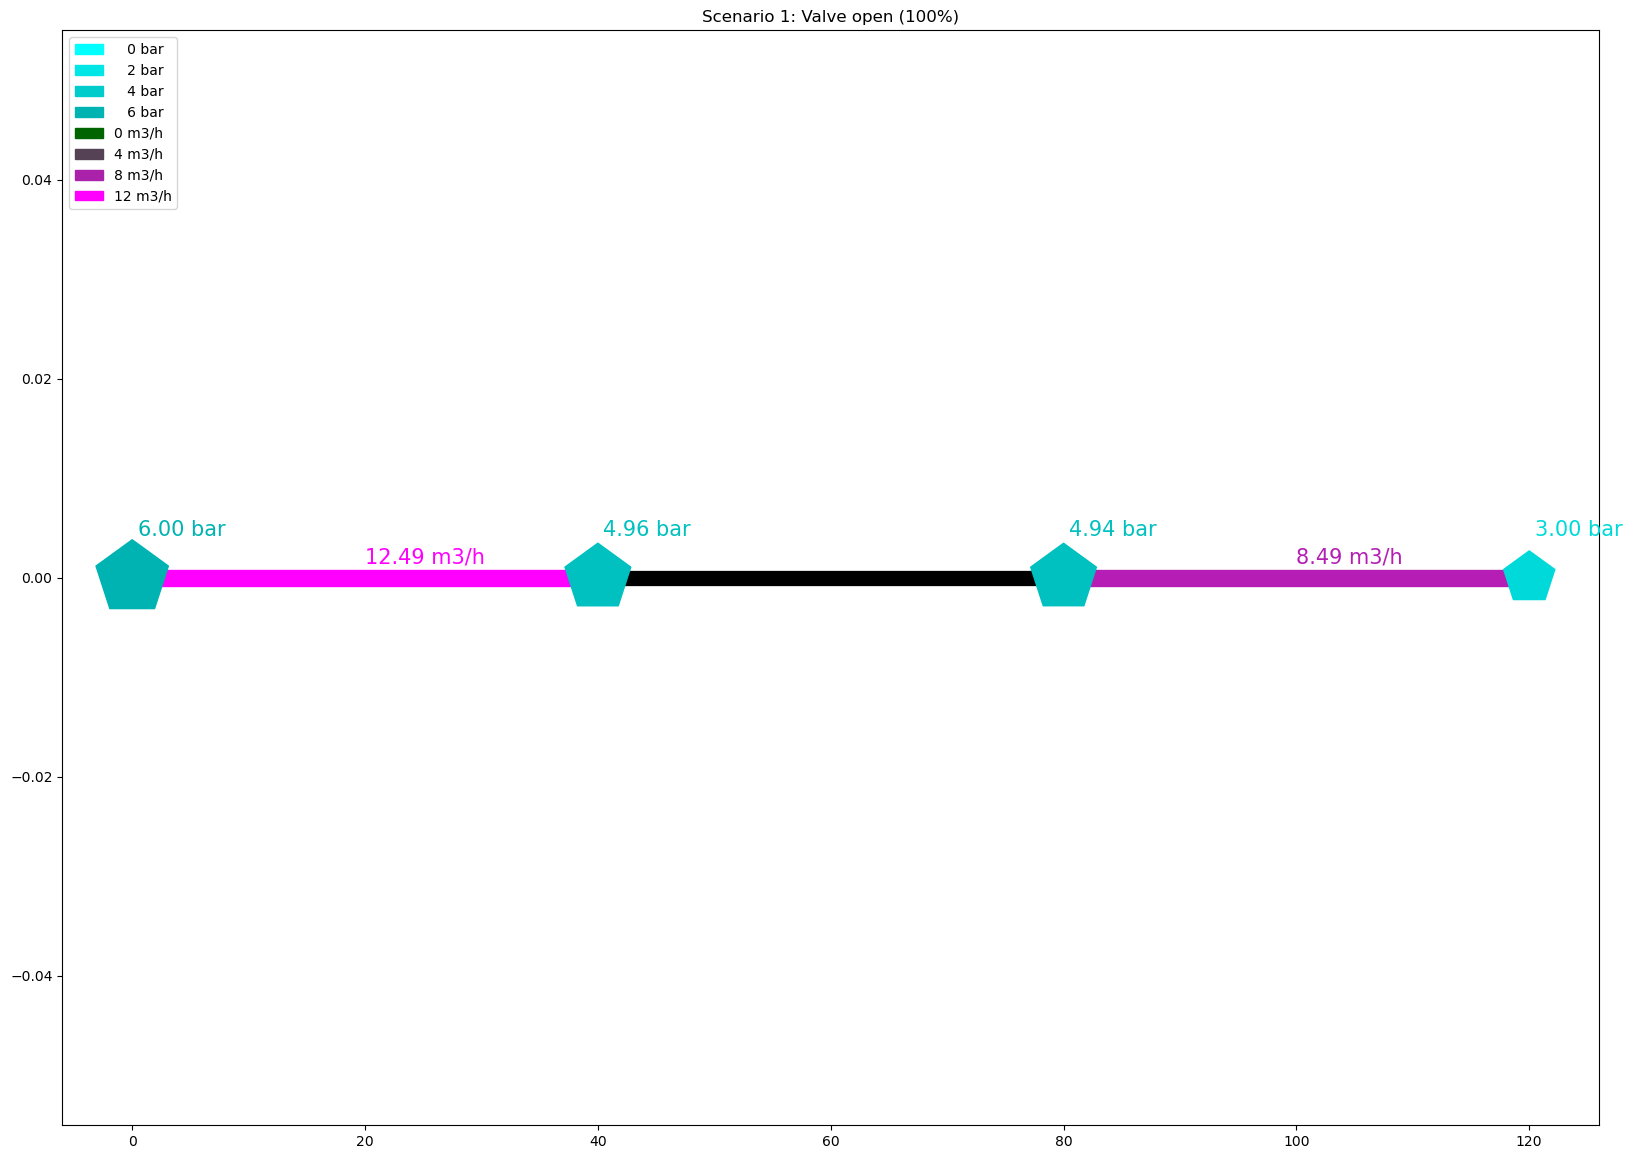

In [30]:
plot_Result_ncd(df_nodes=df_nodes_1, df_pipes=df_pipes_1, axTitle='Scenario 1: Valve open (100%)', valve_percentage=100)

Note that due to the simplicitiy of the model we consider, we will actually have some net outflow on the right most node.

[2026-06-08 11:21:09,732] INFO in sir3stoolkit.mantle.plotting: [plot] Plotting nodes (size='None', color='None', attr='P')
[2026-06-08 11:21:09,754] INFO in sir3stoolkit.mantle.plotting: [plot] Nodes: plotted 4 points.
[2026-06-08 11:21:09,760] INFO in sir3stoolkit.mantle.plotting: [plot] Plotting pipes (width='DN', color='QMAV', attr='None')
[2026-06-08 11:21:09,778] INFO in sir3stoolkit.mantle.plotting: [plot] Pipes: plotted 2 segments.


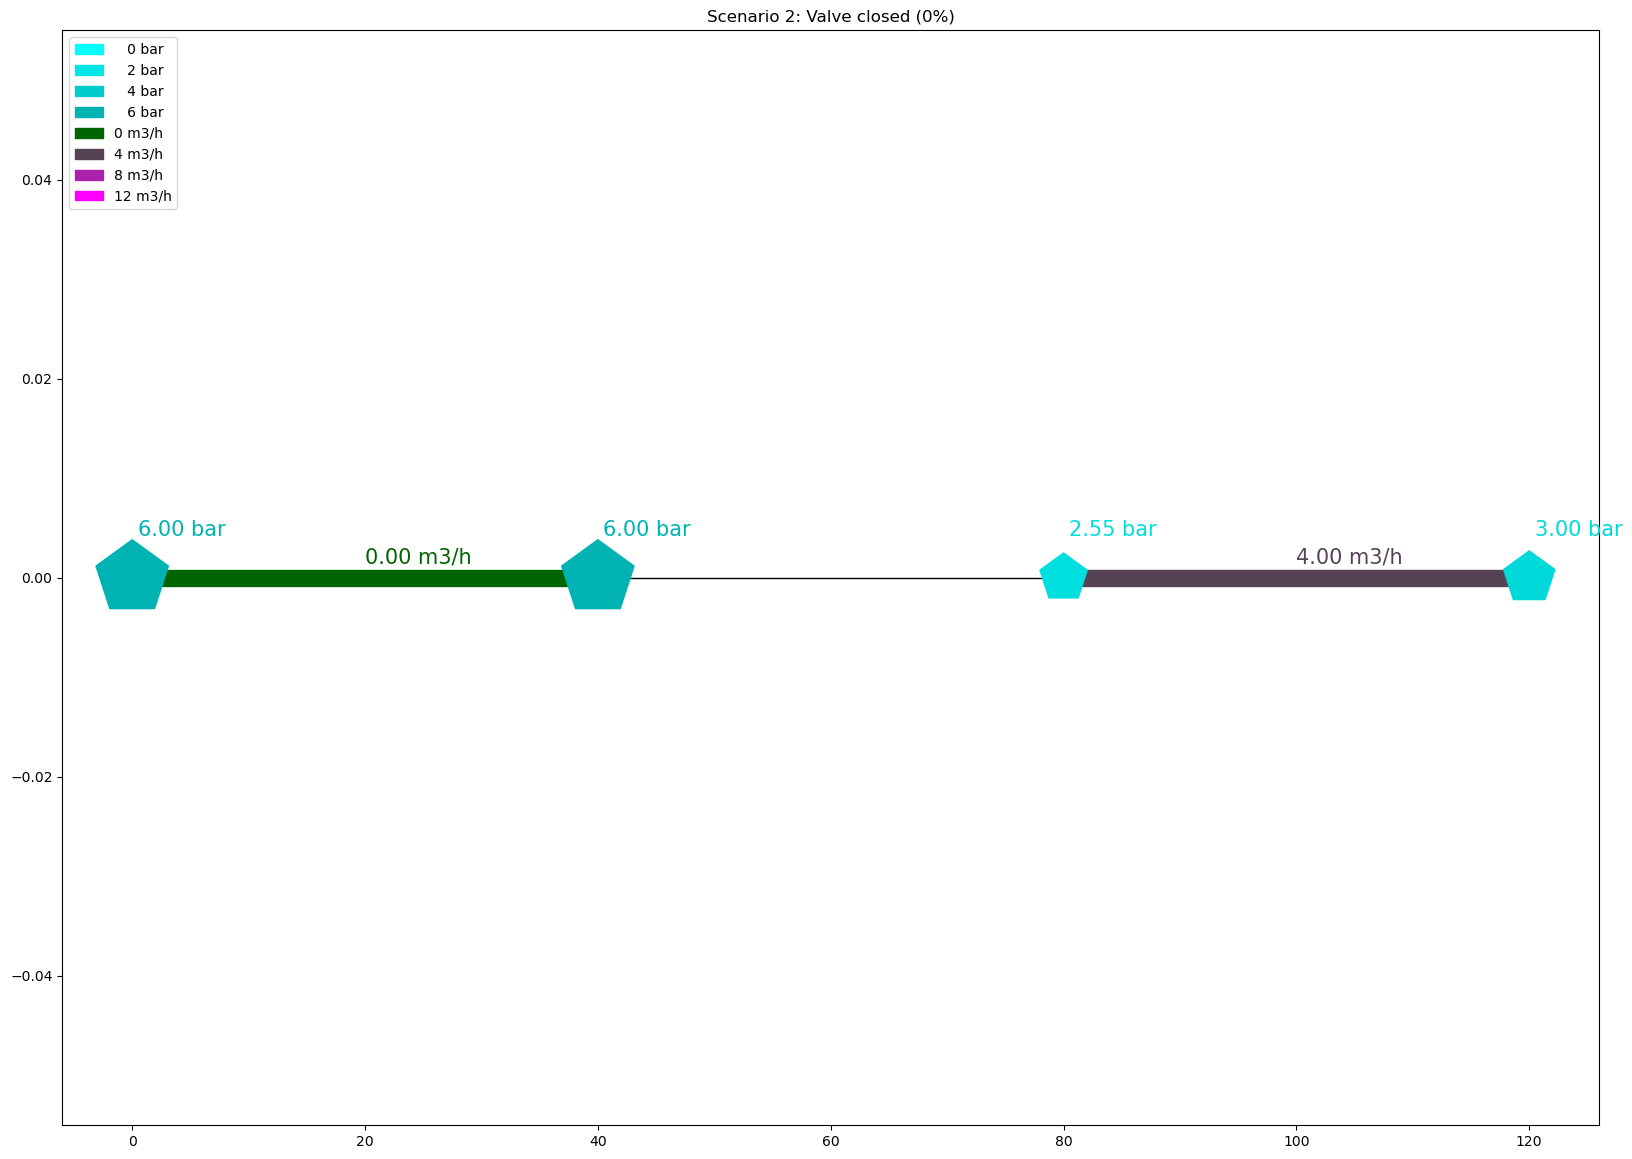

In [31]:
plot_Result_ncd(df_nodes=df_nodes_2, df_pipes=df_pipes_2, axTitle='Scenario 2: Valve closed (0%)', valve_percentage=0)

Now the left and right part are completley decoupled as the valve is shut.

[2026-06-08 11:21:10,714] INFO in sir3stoolkit.mantle.plotting: [plot] Plotting nodes (size='None', color='None', attr='P')
[2026-06-08 11:21:10,738] INFO in sir3stoolkit.mantle.plotting: [plot] Nodes: plotted 4 points.
[2026-06-08 11:21:10,739] INFO in sir3stoolkit.mantle.plotting: [plot] Plotting pipes (width='DN', color='QMAV', attr='None')
[2026-06-08 11:21:10,761] INFO in sir3stoolkit.mantle.plotting: [plot] Pipes: plotted 2 segments.


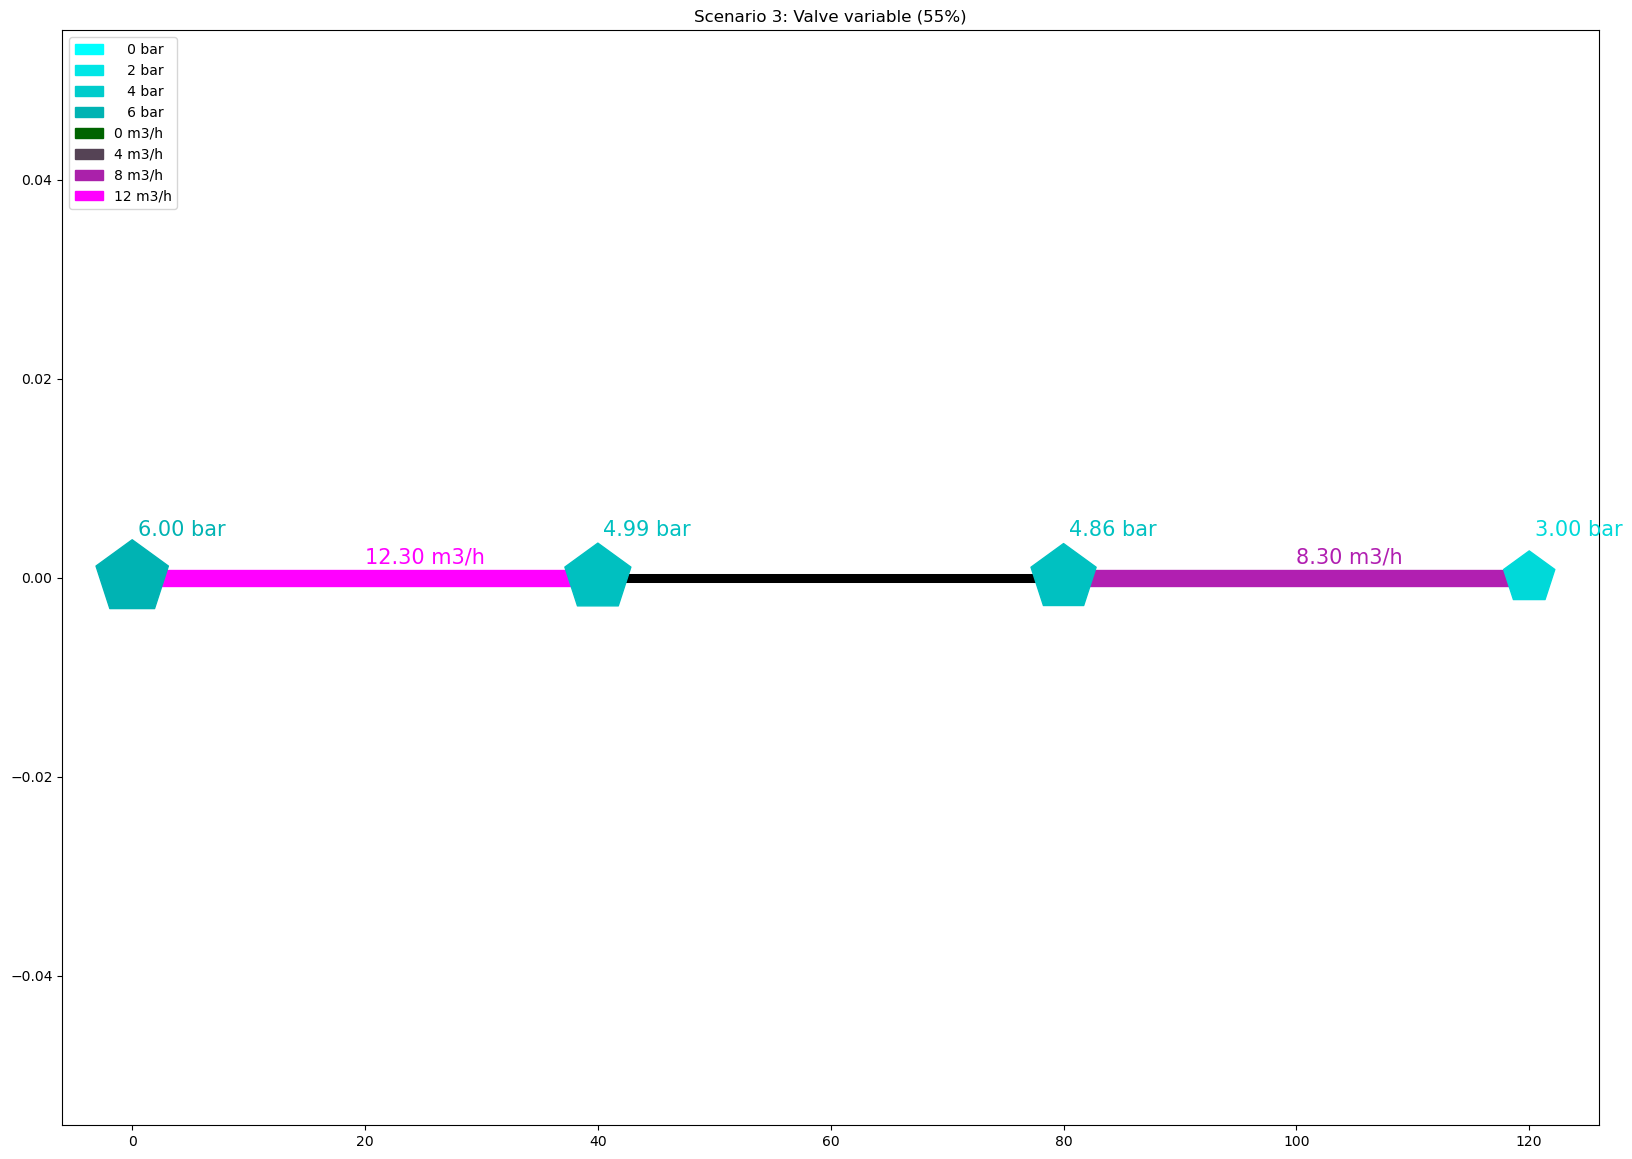

In [32]:
plot_Result_ncd(df_nodes=df_nodes_3, df_pipes=df_pipes_3, axTitle='Scenario 3: Valve variable (55%)', valve_percentage=55)

We can observe a large pressure drop across the valve than at 100 % opening.

In [33]:
s3s.CloseModel(False)

True